# Potential Talents 

As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

## Imports

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
import nltk

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer




## EDA

In [2]:
# loading the csv
file_path = "../data/raw/potential-talents - Aspiring human resources - seeking human resources.csv"
data = pd.read_csv(file_path)

In [3]:
data.head(5)

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [4]:
data.shape

(104, 5)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    str    
 2   location    104 non-null    str    
 3   connection  104 non-null    str    
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), str(3)
memory usage: 4.2 KB


No missing data other than the 'fit' column. This makes sense as that is the 'target' feature

In [6]:
#drop ID, not needed since it gives no characteristic information
data_clean = data.drop(columns='id') 
#convert connections column to numeric
data_clean['connection'] = data_clean['connection'].replace(to_replace=r'500\+\s*',value=500, regex=True)
data_clean['connection'] = pd.to_numeric(data_clean['connection'])
data_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   job_title   104 non-null    str    
 1   location    104 non-null    str    
 2   connection  104 non-null    int64  
 3   fit         0 non-null      float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.4 KB


In [7]:

data_clean.drop_duplicates(keep='first', inplace=True)
data_clean.shape



(53, 4)

In [8]:
#over_500_connections = data_clean[data_clean['connection'] == 500] 


In [9]:
#data2 = data[['job_title','location','connection']].drop_duplicates(keep='first')
#data2

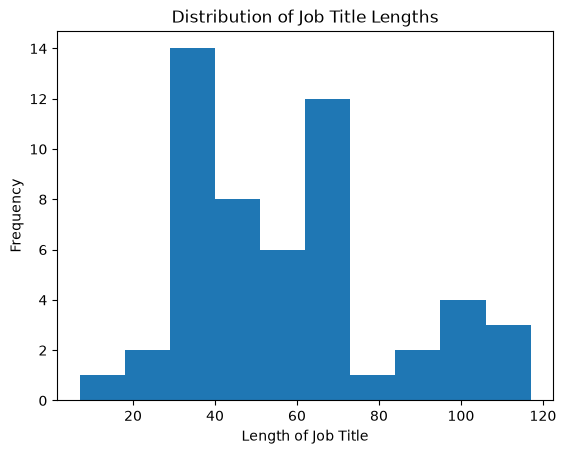

In [10]:
data_clean["job_title"].str.len().plot(kind="hist", bins=10)

plt.xlabel("Length of Job Title")
plt.ylabel("Frequency")
plt.title("Distribution of Job Title Lengths")
plt.show()

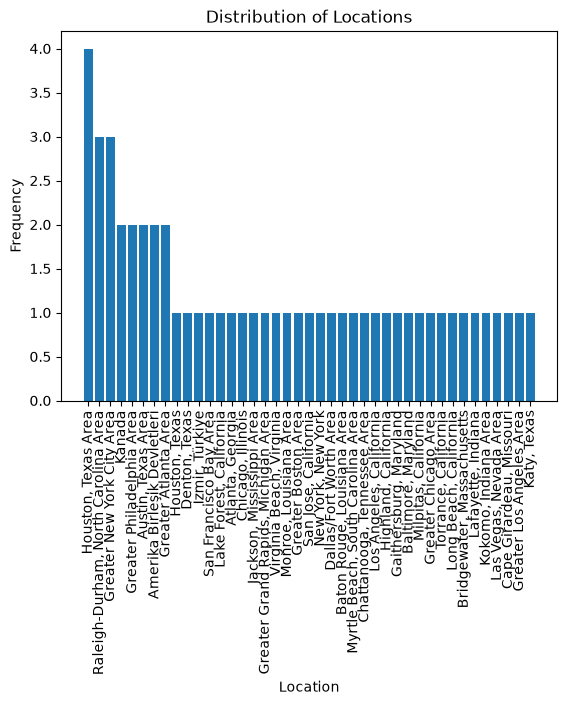

In [11]:
locations = data_clean["location"].value_counts()
plt.bar(locations.index, locations.values)
plt.xticks(rotation=90)
plt.xlabel("Location")
plt.ylabel("Frequency")
plt.title("Distribution of Locations")

plt.show()

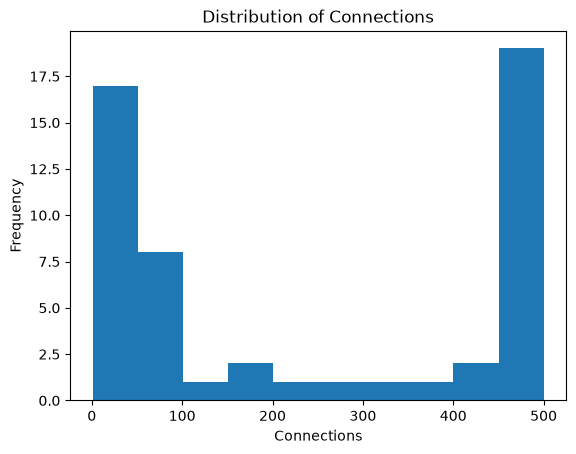

In [12]:
data_clean["connection"].plot(kind="hist", bins=10)

plt.xlabel("Connections")
plt.ylabel("Frequency")
plt.title("Distribution of Connections")

plt.show()

## Text Preprocessing

### Text Cleaning

In [13]:
#convert column to lowercase
data_clean['job_title'] = data_clean['job_title'].str.lower()
data_clean['location'] = data_clean['location'].str.lower()

#remove puncuation and whitespace
data_clean['job_title'] = data_clean['job_title'].str.replace(r'[^\w\s]', '', regex=True)
data_clean['location'] = data_clean['location'].str.replace(r'[^\w\s]', '', regex=True)

#remove numerics
data_clean['job_title'] = data_clean['job_title'].str.replace(r'\d+', '', regex=True)

#remove accents from characters
data_clean['location'] = data_clean['location'].str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("utf-8")

In [14]:
data_clean.head()

,job_title,location,connection,fit
0,ct bauer college of business graduate magna c...,houston texas,85,NaN
1,native english teacher at epik english program...,kanada,500,NaN
2,aspiring human resources professional,raleighdurham north carolina area,44,NaN
3,people development coordinator at ryan,denton texas,500,NaN
4,advisory board member at celal bayar university,izmir turkiye,500,NaN


### Tokenization

In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')

data_clean['tokens'] = data_clean['job_title'].apply(nltk.word_tokenize)
data_clean.head()

[nltk_data] Downloading package punkt to /Users/megmkr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/megmkr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,job_title,location,connection,fit,tokens
0,ct bauer college of business graduate magna c...,houston texas,85,NaN,"[ct, bauer, college, of, business, graduate, m..."
1,native english teacher at epik english program...,kanada,500,NaN,"[native, english, teacher, at, epik, english, ..."
2,aspiring human resources professional,raleighdurham north carolina area,44,NaN,"[aspiring, human, resources, professional]"
3,people development coordinator at ryan,denton texas,500,NaN,"[people, development, coordinator, at, ryan]"
4,advisory board member at celal bayar university,izmir turkiye,500,NaN,"[advisory, board, member, at, celal, bayar, un..."


### Stopword Removal

In [18]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
filtered_corpus = [[word for word in doc if word not in stop_words] for doc in data_clean['tokens']]
print("Stopword Removed Corpus:\n", filtered_corpus)

Stopword Removed Corpus:
 [['ct', 'bauer', 'college', 'business', 'graduate', 'magna', 'cum', 'laude', 'aspiring', 'human', 'resources', 'professional'], ['native', 'english', 'teacher', 'epik', 'english', 'program', 'korea'], ['aspiring', 'human', 'resources', 'professional'], ['people', 'development', 'coordinator', 'ryan'], ['advisory', 'board', 'member', 'celal', 'bayar', 'university'], ['aspiring', 'human', 'resources', 'specialist'], ['student', 'humber', 'college', 'aspiring', 'human', 'resources', 'generalist'], ['hr', 'senior', 'specialist'], ['seeking', 'human', 'resources', 'hris', 'generalist', 'positions'], ['student', 'chapman', 'university'], ['svp', 'chro', 'marketing', 'communications', 'csr', 'officer', 'engie', 'houston', 'woodlands', 'energy', 'gphr', 'sphr'], ['human', 'resources', 'coordinator', 'intercontinental', 'buckhead', 'atlanta'], ['aspiring', 'human', 'resources', 'management', 'student', 'seeking', 'internship'], ['seeking', 'human', 'resources', 'opport

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/megmkr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Stemming

In [20]:
stemmer = PorterStemmer()
stemmed_corpus = [[stemmer.stem(word) for word in doc] for doc in filtered_corpus]
print("Stemmed Corpus:\n", stemmed_corpus)

Stemmed Corpus:
 [['ct', 'bauer', 'colleg', 'busi', 'graduat', 'magna', 'cum', 'laud', 'aspir', 'human', 'resourc', 'profession'], ['nativ', 'english', 'teacher', 'epik', 'english', 'program', 'korea'], ['aspir', 'human', 'resourc', 'profession'], ['peopl', 'develop', 'coordin', 'ryan'], ['advisori', 'board', 'member', 'celal', 'bayar', 'univers'], ['aspir', 'human', 'resourc', 'specialist'], ['student', 'humber', 'colleg', 'aspir', 'human', 'resourc', 'generalist'], ['hr', 'senior', 'specialist'], ['seek', 'human', 'resourc', 'hri', 'generalist', 'posit'], ['student', 'chapman', 'univers'], ['svp', 'chro', 'market', 'commun', 'csr', 'offic', 'engi', 'houston', 'woodland', 'energi', 'gphr', 'sphr'], ['human', 'resourc', 'coordin', 'intercontinent', 'buckhead', 'atlanta'], ['aspir', 'human', 'resourc', 'manag', 'student', 'seek', 'internship'], ['seek', 'human', 'resourc', 'opportun'], ['experienc', 'retail', 'manag', 'aspir', 'human', 'resourc', 'profession'], ['human', 'resourc', 'sta

### Lemmatization

In [22]:
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
lemmatized_corpus = [[lemmatizer.lemmatize(word) for word in doc] for doc in filtered_corpus]
print("Lemmatized Corpus:\n", lemmatized_corpus)


[nltk_data] Downloading package wordnet to /Users/megmkr/nltk_data...


Lemmatized Corpus:
 [['ct', 'bauer', 'college', 'business', 'graduate', 'magna', 'cum', 'laude', 'aspiring', 'human', 'resource', 'professional'], ['native', 'english', 'teacher', 'epik', 'english', 'program', 'korea'], ['aspiring', 'human', 'resource', 'professional'], ['people', 'development', 'coordinator', 'ryan'], ['advisory', 'board', 'member', 'celal', 'bayar', 'university'], ['aspiring', 'human', 'resource', 'specialist'], ['student', 'humber', 'college', 'aspiring', 'human', 'resource', 'generalist'], ['hr', 'senior', 'specialist'], ['seeking', 'human', 'resource', 'hris', 'generalist', 'position'], ['student', 'chapman', 'university'], ['svp', 'chro', 'marketing', 'communication', 'csr', 'officer', 'engie', 'houston', 'woodland', 'energy', 'gphr', 'sphr'], ['human', 'resource', 'coordinator', 'intercontinental', 'buckhead', 'atlanta'], ['aspiring', 'human', 'resource', 'management', 'student', 'seeking', 'internship'], ['seeking', 'human', 'resource', 'opportunity'], ['experi